In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-02-08 13:24:14.905551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import sys

os.makedirs('../saved_models', exist_ok=True)
os.makedirs('../results', exist_ok=True)
os.makedirs('../logs', exist_ok=True)

CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']


class Tee:
    def __init__(self, *streams):
        self.streams = streams
        self.encoding = getattr(streams[0], 'encoding', 'utf-8')
    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()
    def flush(self):
        for s in self.streams:
            s.flush()


log_file = open('../logs/gru_skipgram.txt', 'w')
sys.stdout = Tee(sys.__stdout__, log_file)
sys.stderr = Tee(sys.__stderr__, log_file)

## preprocessing

In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def load_and_preprocess(train_path='../data/train.csv', test_path='../data/test.csv'):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    for df in [train_df, test_df]:
        df['Title'] = df['Title'].fillna('')
        df['Description'] = df['Description'].fillna('')
        df['text'] = (df['Title'] + ' ' + df['Description']).apply(preprocess_text)
        df['label'] = df['Class Index'] - 1

    X_train, X_val, y_train, y_val = train_test_split(
        train_df['text'].values, train_df['label'].values,
        test_size=0.2, random_state=42, stratify=train_df['label'].values
    )

    X_test = test_df['text'].values
    y_test = test_df['label'].values

    return X_train, X_val, X_test, y_train, y_val, y_test

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess()
print(f'train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}')

## tokenization

In [5]:
VOCAB_SIZE = 20000
MAX_SEQ_LEN = 200
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

train_sequences = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
val_sequences = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
test_sequences = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

## train skip-gram word2vec

In [6]:
train_corpus = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=train_corpus,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=10
)

w2v_model.save('../saved_models/skipgram_w2v.model')
print(f'skip-gram vocab size: {len(w2v_model.wv)}')

In [7]:
word_index = tokenizer.word_index
num_words = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBED_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= num_words:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1

print(f'embedded {found}/{num_words} words')

## model

In [8]:
def build_gru_skipgram(vocab_size, embed_dim, seq_len, embed_matrix, gru_units=128, dropout_rate=0.3, learning_rate=1e-3):
    inp = Input(shape=(seq_len,))
    x = Embedding(vocab_size, embed_dim, weights=[embed_matrix], trainable=False, mask_zero=True)(inp)
    x = GRU(gru_units)(x)
    x = Dropout(dropout_rate)(x)
    out = Dense(4, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## hyperparameter tuning

In [9]:
param_grid = [
    {'gru_units': 64, 'dropout_rate': 0.3, 'learning_rate': 1e-3},
    {'gru_units': 64, 'dropout_rate': 0.5, 'learning_rate': 5e-4},
    {'gru_units': 128, 'dropout_rate': 0.3, 'learning_rate': 1e-3},
    {'gru_units': 128, 'dropout_rate': 0.5, 'learning_rate': 5e-4},
]

best_val_acc = 0
best_params = None
tuning_results = []

for params in param_grid:
    print(f'training with {params}')
    model = build_gru_skipgram(num_words, EMBED_DIM, MAX_SEQ_LEN, embedding_matrix, **params)
    history = model.fit(
        train_sequences, y_train,
        validation_data=(val_sequences, y_val),
        epochs=10,
        batch_size=256,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1
    )
    val_acc = max(history.history['val_accuracy'])
    tuning_results.append({**params, 'val_accuracy': val_acc})
    print(f'val accuracy: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

print(f'\nbest params: {best_params}, val accuracy: {best_val_acc:.4f}')

## train best model

In [10]:
model = build_gru_skipgram(num_words, EMBED_DIM, MAX_SEQ_LEN, embedding_matrix, **best_params)

history = model.fit(
    train_sequences, y_train,
    validation_data=(val_sequences, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

model.save('../saved_models/gru_skipgram.keras')

## training curves

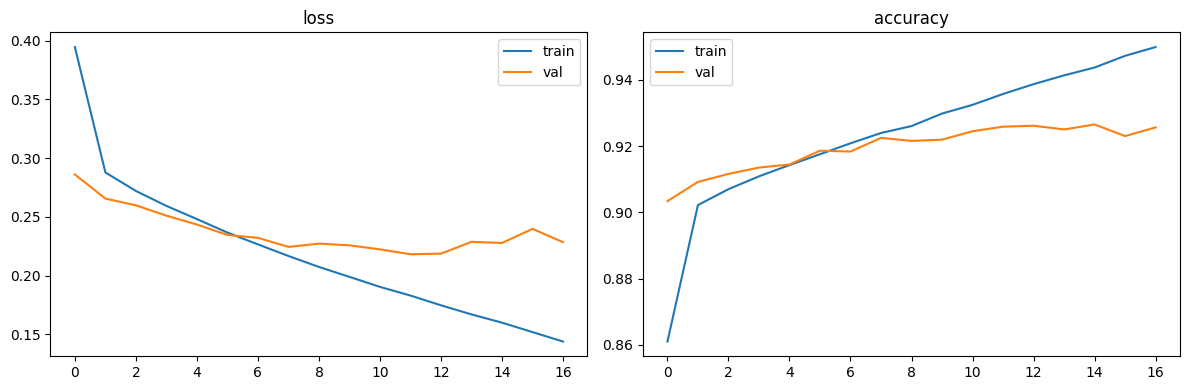

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/gru_skipgram_training_curves.png', dpi=150)
plt.show()

## evaluation

In [12]:
y_pred = np.argmax(model.predict(test_sequences), axis=1)

acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_per_class = f1_score(y_test, y_pred, average=None).tolist()

print(f'test accuracy: {acc:.4f}')
print(f'weighted f1: {f1_weighted:.4f}')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

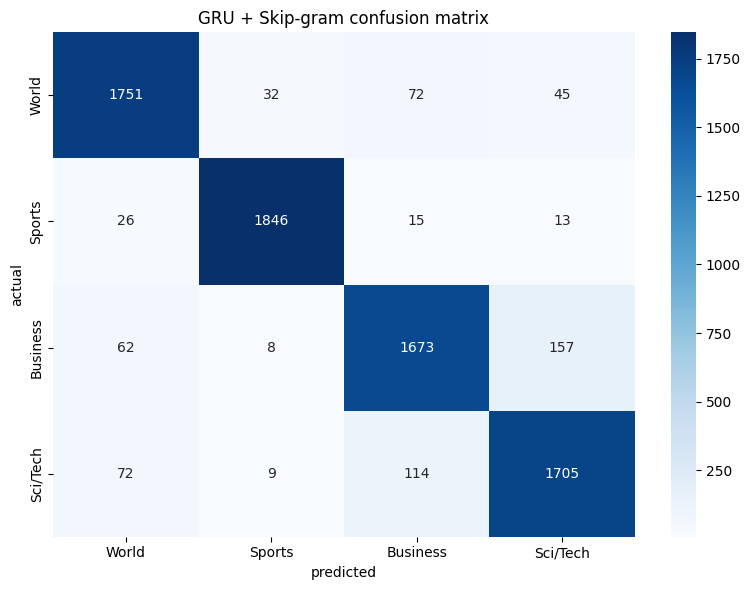

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('GRU + Skip-gram confusion matrix')
plt.tight_layout()
plt.savefig('../results/gru_skipgram_confusion_matrix.png', dpi=150)
plt.show()

In [14]:
results = {
    'model': 'GRU + Skip-gram',
    'best_params': best_params,
    'tuning_results': tuning_results,
    'test_accuracy': acc,
    'weighted_f1': f1_weighted,
    'per_class_f1': {CLASS_NAMES[i]: f1_per_class[i] for i in range(4)}
}

with open('../results/gru_skipgram_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('results saved')